## 1. Setup Environment

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install Ultralytics (YOLOv8)
!pip install ultralytics -q

# Import libraries
import os
import shutil
import yaml
from pathlib import Path
from ultralytics import YOLO
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Load dan Verifikasi Dataset

Memuat path dataset Trans-Ventricular dari Google Drive dan memverifikasi bahwa setiap file gambar memiliki file label yang sesuai.

In [2]:
# Google Drive Path
dataset_path = '/content/drive/MyDrive/ipynb-project/Trans-ventricular'
images_path = os.path.join(dataset_path, 'images')
labels_path = os.path.join(dataset_path, 'labels')

# Verify dataset
image_files = sorted([f for f in os.listdir(images_path) if f.endswith('.png')])
label_files = sorted([f for f in os.listdir(labels_path) if f.endswith('.txt')])

print(f"Total gambar: {len(image_files)}")
print(f"Total label: {len(label_files)}")
print(f"\nContoh gambar: {image_files[:3]}")
print(f"Contoh label: {label_files[:3]}")

# Verify matching files
image_names = {os.path.splitext(f)[0] for f in image_files}
label_names = {os.path.splitext(f)[0] for f in label_files}

missing_labels = image_names - label_names
missing_images = label_names - image_names

if missing_labels:
    print(f"Gambar tanpa label: {len(missing_labels)}")
if missing_images:
    print(f"Label tanpa gambar: {len(missing_images)}")

if not missing_labels and not missing_images:
    print("Semua gambar dan label match!")

Total gambar: 584
Total label: 584

Contoh gambar: ['Patient00188_Plane3_2_of_3.png', 'Patient00216_Plane3_2_of_5.png', 'Patient00305_Plane3_1_of_5.png']
Contoh label: ['Patient00188_Plane3_2_of_3.txt', 'Patient00216_Plane3_2_of_5.txt', 'Patient00305_Plane3_1_of_5.txt']
Semua gambar dan label match!


## 3. Pembagian Dataset (Train/Validation Split)

Membagi dataset dengan rasio 80:20 menggunakan `train_test_split`, lalu menyalin file gambar dan label ke direktori `train` dan `val` masing-masing.

In [3]:
# Create directory for train/val split
base_dir = '/content/dataset'
train_images_dir = os.path.join(base_dir, 'images/train')
val_images_dir = os.path.join(base_dir, 'images/val')
train_labels_dir = os.path.join(base_dir, 'labels/train')
val_labels_dir = os.path.join(base_dir, 'labels/val')

# Create directory
for dir_path in [train_images_dir, val_images_dir, train_labels_dir, val_labels_dir]:
    os.makedirs(dir_path, exist_ok=True)

# Get matching files only
matching_files = list(image_names & label_names)
print(f"Total file matching: {len(matching_files)}")

# Split 80:20
train_files, val_files = train_test_split(matching_files, test_size=0.2, random_state=42)

print(f"Training set: {len(train_files)} files")
print(f"Validation set: {len(val_files)} files")

# Copy files to train folder
print("\nCopying training files...")
for filename in train_files:
    # Copy image
    src_img = os.path.join(images_path, filename + '.png')
    dst_img = os.path.join(train_images_dir, filename + '.png')
    shutil.copy2(src_img, dst_img)

    # Copy label
    src_lbl = os.path.join(labels_path, filename + '.txt')
    dst_lbl = os.path.join(train_labels_dir, filename + '.txt')
    shutil.copy2(src_lbl, dst_lbl)

# Copy files to val folder
print("Copying validation files...")
for filename in val_files:
    # Copy image
    src_img = os.path.join(images_path, filename + '.png')
    dst_img = os.path.join(val_images_dir, filename + '.png')
    shutil.copy2(src_img, dst_img)

    # Copy label
    src_lbl = os.path.join(labels_path, filename + '.txt')
    dst_lbl = os.path.join(val_labels_dir, filename + '.txt')
    shutil.copy2(src_lbl, dst_lbl)

print("Dataset split selesai")

Total file matching: 584
Training set: 467 files
Validation set: 117 files

Copying training files...
Copying validation files...
Dataset split selesai


## 4. Remapping Class ID

Dataset asli menggunakan class ID 1 (CSP) dan 2 (LV). YOLO mengharuskan class ID dimulai dari 0, sehingga dilakukan remapping: class 1 → 0 dan class 2 → 1.

In [4]:
# Remap class ID from 1,2 to 0,1
print("Remapping class IDs...")

def remap_class_ids(label_dir):
    """Remap class 1→0, class 2→1"""
    for label_file in os.listdir(label_dir):
        if not label_file.endswith('.txt'):
            continue

        file_path = os.path.join(label_dir, label_file)

        # Read original content
        with open(file_path, 'r') as f:
            lines = f.readlines()

        # Remap class IDs
        new_lines = []
        for line in lines:
            if line.strip():
                parts = line.strip().split()
                old_class_id = int(parts[0])

                # Remap: 1→0, 2→1
                if old_class_id == 1:
                    new_class_id = 0
                elif old_class_id == 2:
                    new_class_id = 1
                else:
                    continue  # Skip class 0 (Brain) jika ada

                new_line = f"{new_class_id} {' '.join(parts[1:])}\n"
                new_lines.append(new_line)

        # Write back
        with open(file_path, 'w') as f:
            f.writelines(new_lines)

# Remap untuk train dan val
remap_class_ids(train_labels_dir)
remap_class_ids(val_labels_dir)

print("Class ID remapping selesai")
print("   Class 1 (CSP) → Class 0")
print("   Class 2 (LV)  → Class 1")

Remapping class IDs...
Class ID remapping selesai
   Class 1 (CSP) → Class 0
   Class 2 (LV)  → Class 1


## 5. Analisis Distribusi Class

Menghitung jumlah objek per class pada training set dan validation set, visualisasi distribusinya ditampilkan dalam bentuk bar chart.

DISTRIBUSI CLASS - TRAINING SET:
   Total objects: 800
   Class 0 (CSP): 357 (44.6%)
   Class 1 (LV): 443 (55.4%)

DISTRIBUSI CLASS - VALIDATION SET:
   Total objects: 288
   Class 0 (CSP): 126 (43.8%)
   Class 1 (LV): 162 (56.2%)


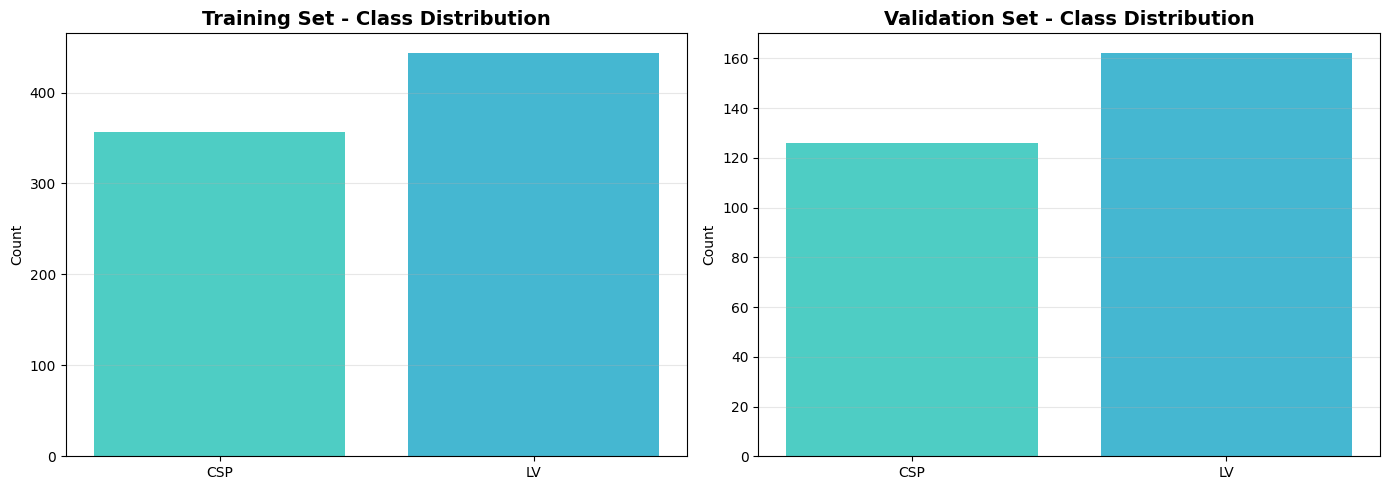

In [5]:
# Class distribution analysis
def analyze_classes(labels_dir):
    class_counts = {0: 0, 1: 0}  # CSP, LV
    total_objects = 0

    for label_file in os.listdir(labels_dir):
        if not label_file.endswith('.txt'):
            continue
        with open(os.path.join(labels_dir, label_file), 'r') as f:
            for line in f:
                if line.strip():
                    class_id = int(line.split()[0])
                    class_counts[class_id] = class_counts.get(class_id, 0) + 1
                    total_objects += 1

    return class_counts, total_objects

train_counts, train_total = analyze_classes(train_labels_dir)
val_counts, val_total = analyze_classes(val_labels_dir)

print("DISTRIBUSI CLASS - TRAINING SET:")
print(f"   Total objects: {train_total}")
for class_id, count in sorted(train_counts.items()):
    class_name = {0: 'CSP', 1: 'LV'}.get(class_id, f'Class_{class_id}')
    percentage = (count / train_total * 100) if train_total > 0 else 0
    print(f"   Class {class_id} ({class_name}): {count} ({percentage:.1f}%)")

print(f"\nDISTRIBUSI CLASS - VALIDATION SET:")
print(f"   Total objects: {val_total}")
for class_id, count in sorted(val_counts.items()):
    class_name = {0: 'CSP', 1: 'LV'}.get(class_id, f'Class_{class_id}')
    percentage = (count / val_total * 100) if val_total > 0 else 0
    print(f"   Class {class_id} ({class_name}): {count} ({percentage:.1f}%)")

# Visualisasi distribusi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

classes = ['CSP', 'LV']
train_values = [train_counts.get(i, 0) for i in range(2)]
val_values = [val_counts.get(i, 0) for i in range(2)]

ax1.bar(classes, train_values, color=['#4ECDC4', '#45B7D1'])
ax1.set_title('Training Set - Class Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Count')
ax1.grid(axis='y', alpha=0.3)

ax2.bar(classes, val_values, color=['#4ECDC4', '#45B7D1'])
ax2.set_title('Validation Set - Class Distribution', fontsize=14, fontweight='bold')
ax2.set_ylabel('Count')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Konfigurasi Dataset (data.yaml)

Membuat file konfigurasi `data.yaml` yang diperlukan oleh YOLOv8, berisi path dataset, jumlah class, dan nama class (CSP dan LV).

In [6]:
# Create data.yaml for YOLOv8
data_yaml = {
    'path': base_dir,
    'train': 'images/train',
    'val': 'images/val',
    'nc': 2,  # number of classes
    'names': {
        0: 'CSP',   # Class 1 di anotasi → Class 0 di YOLO
        1: 'LV'     # Class 2 di anotasi → Class 1 di YOLO
    }
}

yaml_path = os.path.join(base_dir, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("File data.yaml berhasil dibuat!")
print(f"Lokasi: {yaml_path}")
print("\n📄 Isi file:")
with open(yaml_path, 'r') as f:
    print(f.read())

File data.yaml berhasil dibuat!
Lokasi: /content/dataset/data.yaml

📄 Isi file:
path: /content/dataset
train: images/train
val: images/val
nc: 2
names:
  0: CSP
  1: LV



## 7. Training Model YOLOv8

Melatih model YOLOv8n menggunakan dataset Trans-Ventricular selama maksimal 100 epoch dengan ukuran input 640×640. Early stopping diterapkan dengan patience 20 epoch untuk mencegah overfitting.

In [7]:
# Initialize YOLOv8 model
model = YOLO('yolov8n.pt')

# Training
results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    save=True,
    project='runs/detect',
    name='trans_ventricular',
    plots=True,
    device=0
)

print("Training selesai")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=trans_ventricular4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, pers

## 8. Evaluasi Model

Memuat bobot terbaik hasil training (`best.pt`) dan mengevaluasi performa model pada validation set. Metrik yang ditampilkan meliputi mAP@0.5, mAP@0.5:0.95, Precision, dan Recall secara keseluruhan maupun per class (CSP dan LV).

In [26]:
# Load best model
best_model = YOLO('runs/detect/runs/detect/trans_ventricular4/weights/best.pt')

# Validation
val_results = best_model.val(data=yaml_path)

# Print metrics
print("HASIL EVALUASI MODEL")
print(f"mAP@0.5    : {val_results.box.map50:.4f}")
print(f"mAP@0.5:0.95: {val_results.box.map:.4f}")
print(f"Precision  : {val_results.box.mp:.4f}")
print(f"Recall     : {val_results.box.mr:.4f}")

# Per-class metrics
print("\nMETRIK PER CLASS:")
for i, class_name in enumerate(['CSP', 'LV']):
    if i < len(val_results.box.maps):
        print(f"  {class_name}:")
        print(f"    - mAP@0.5: {val_results.box.maps[i]:.4f}")
        print(f"    - Precision: {val_results.box.p[i]:.4f}")
        print(f"    - Recall: {val_results.box.r[i]:.4f}")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2652.8±134.2 MB/s, size: 324.7 KB)
val: Scanning /content/dataset/labels/val.cache... 206 images, 39 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 206/206 61.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.2it/s 5.9s
                   all        206        288      0.961      0.973       0.98      0.733
                   CSP        126        126      0.958      0.976      0.969      0.706
                    LV        162        162      0.964      0.969       0.99      0.761
Speed: 4.4ms preprocess, 4.1ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/detect/val3
HASIL EVALUASI MODEL
mAP@0.5    : 0.9795
mAP@0.5:0.95: 0.7333
Precision  : 0.9610
Recall     : 0.9727


## 9. Visualisasi Hasil Training

Menampilkan grafik training curves (loss dan metrik per epoch) serta confusion matrix yang dihasilkan secara otomatis oleh Ultralytics selama proses pelatihan.


results.png


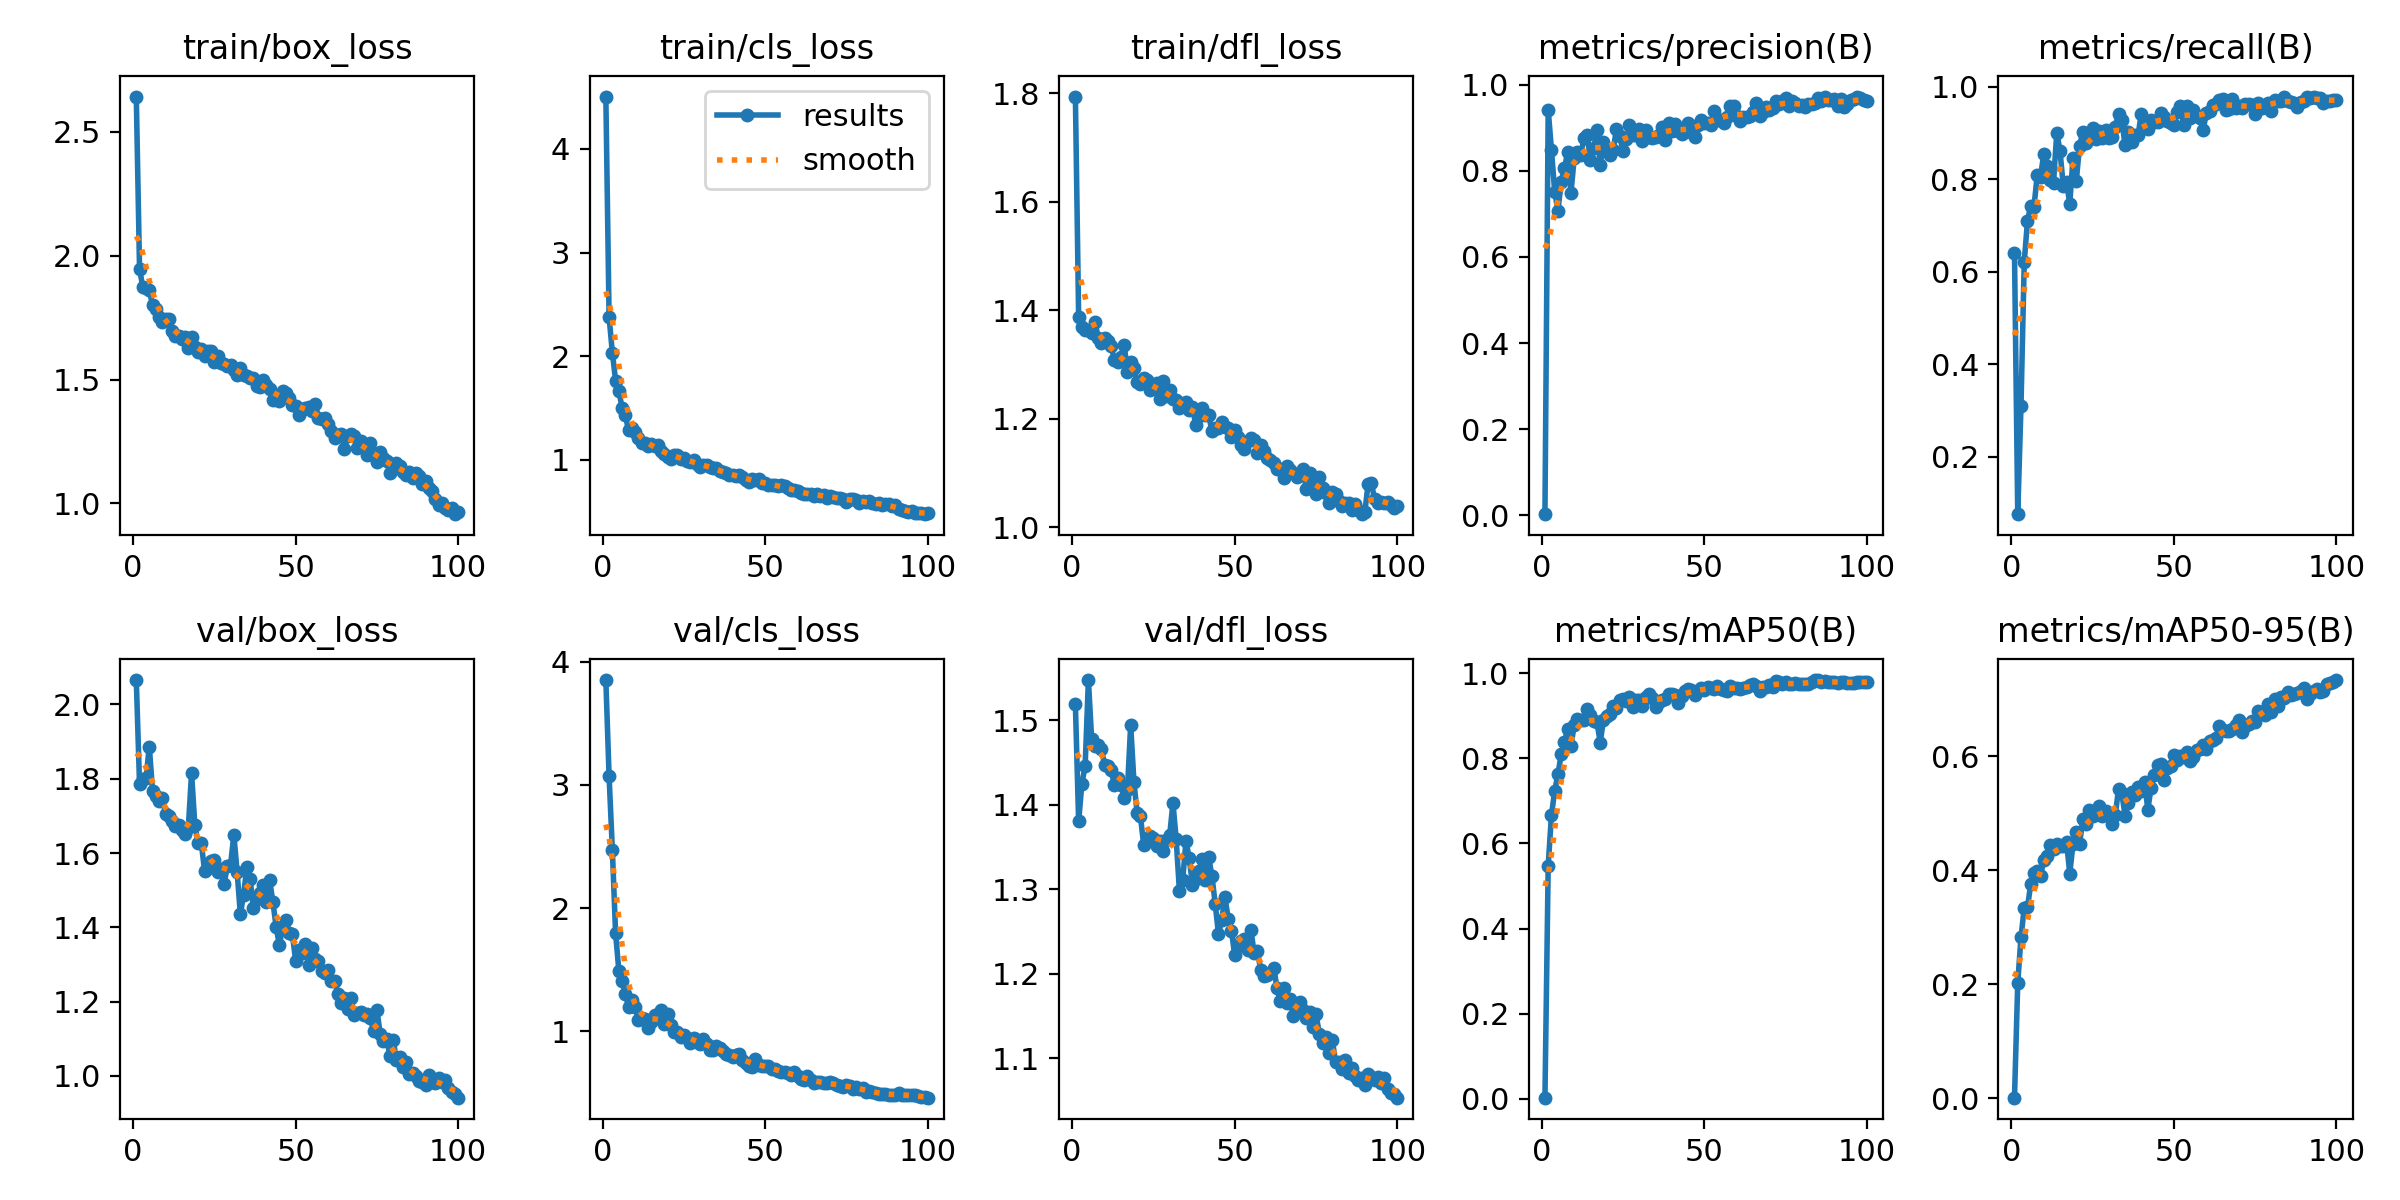


confusion_matrix.png


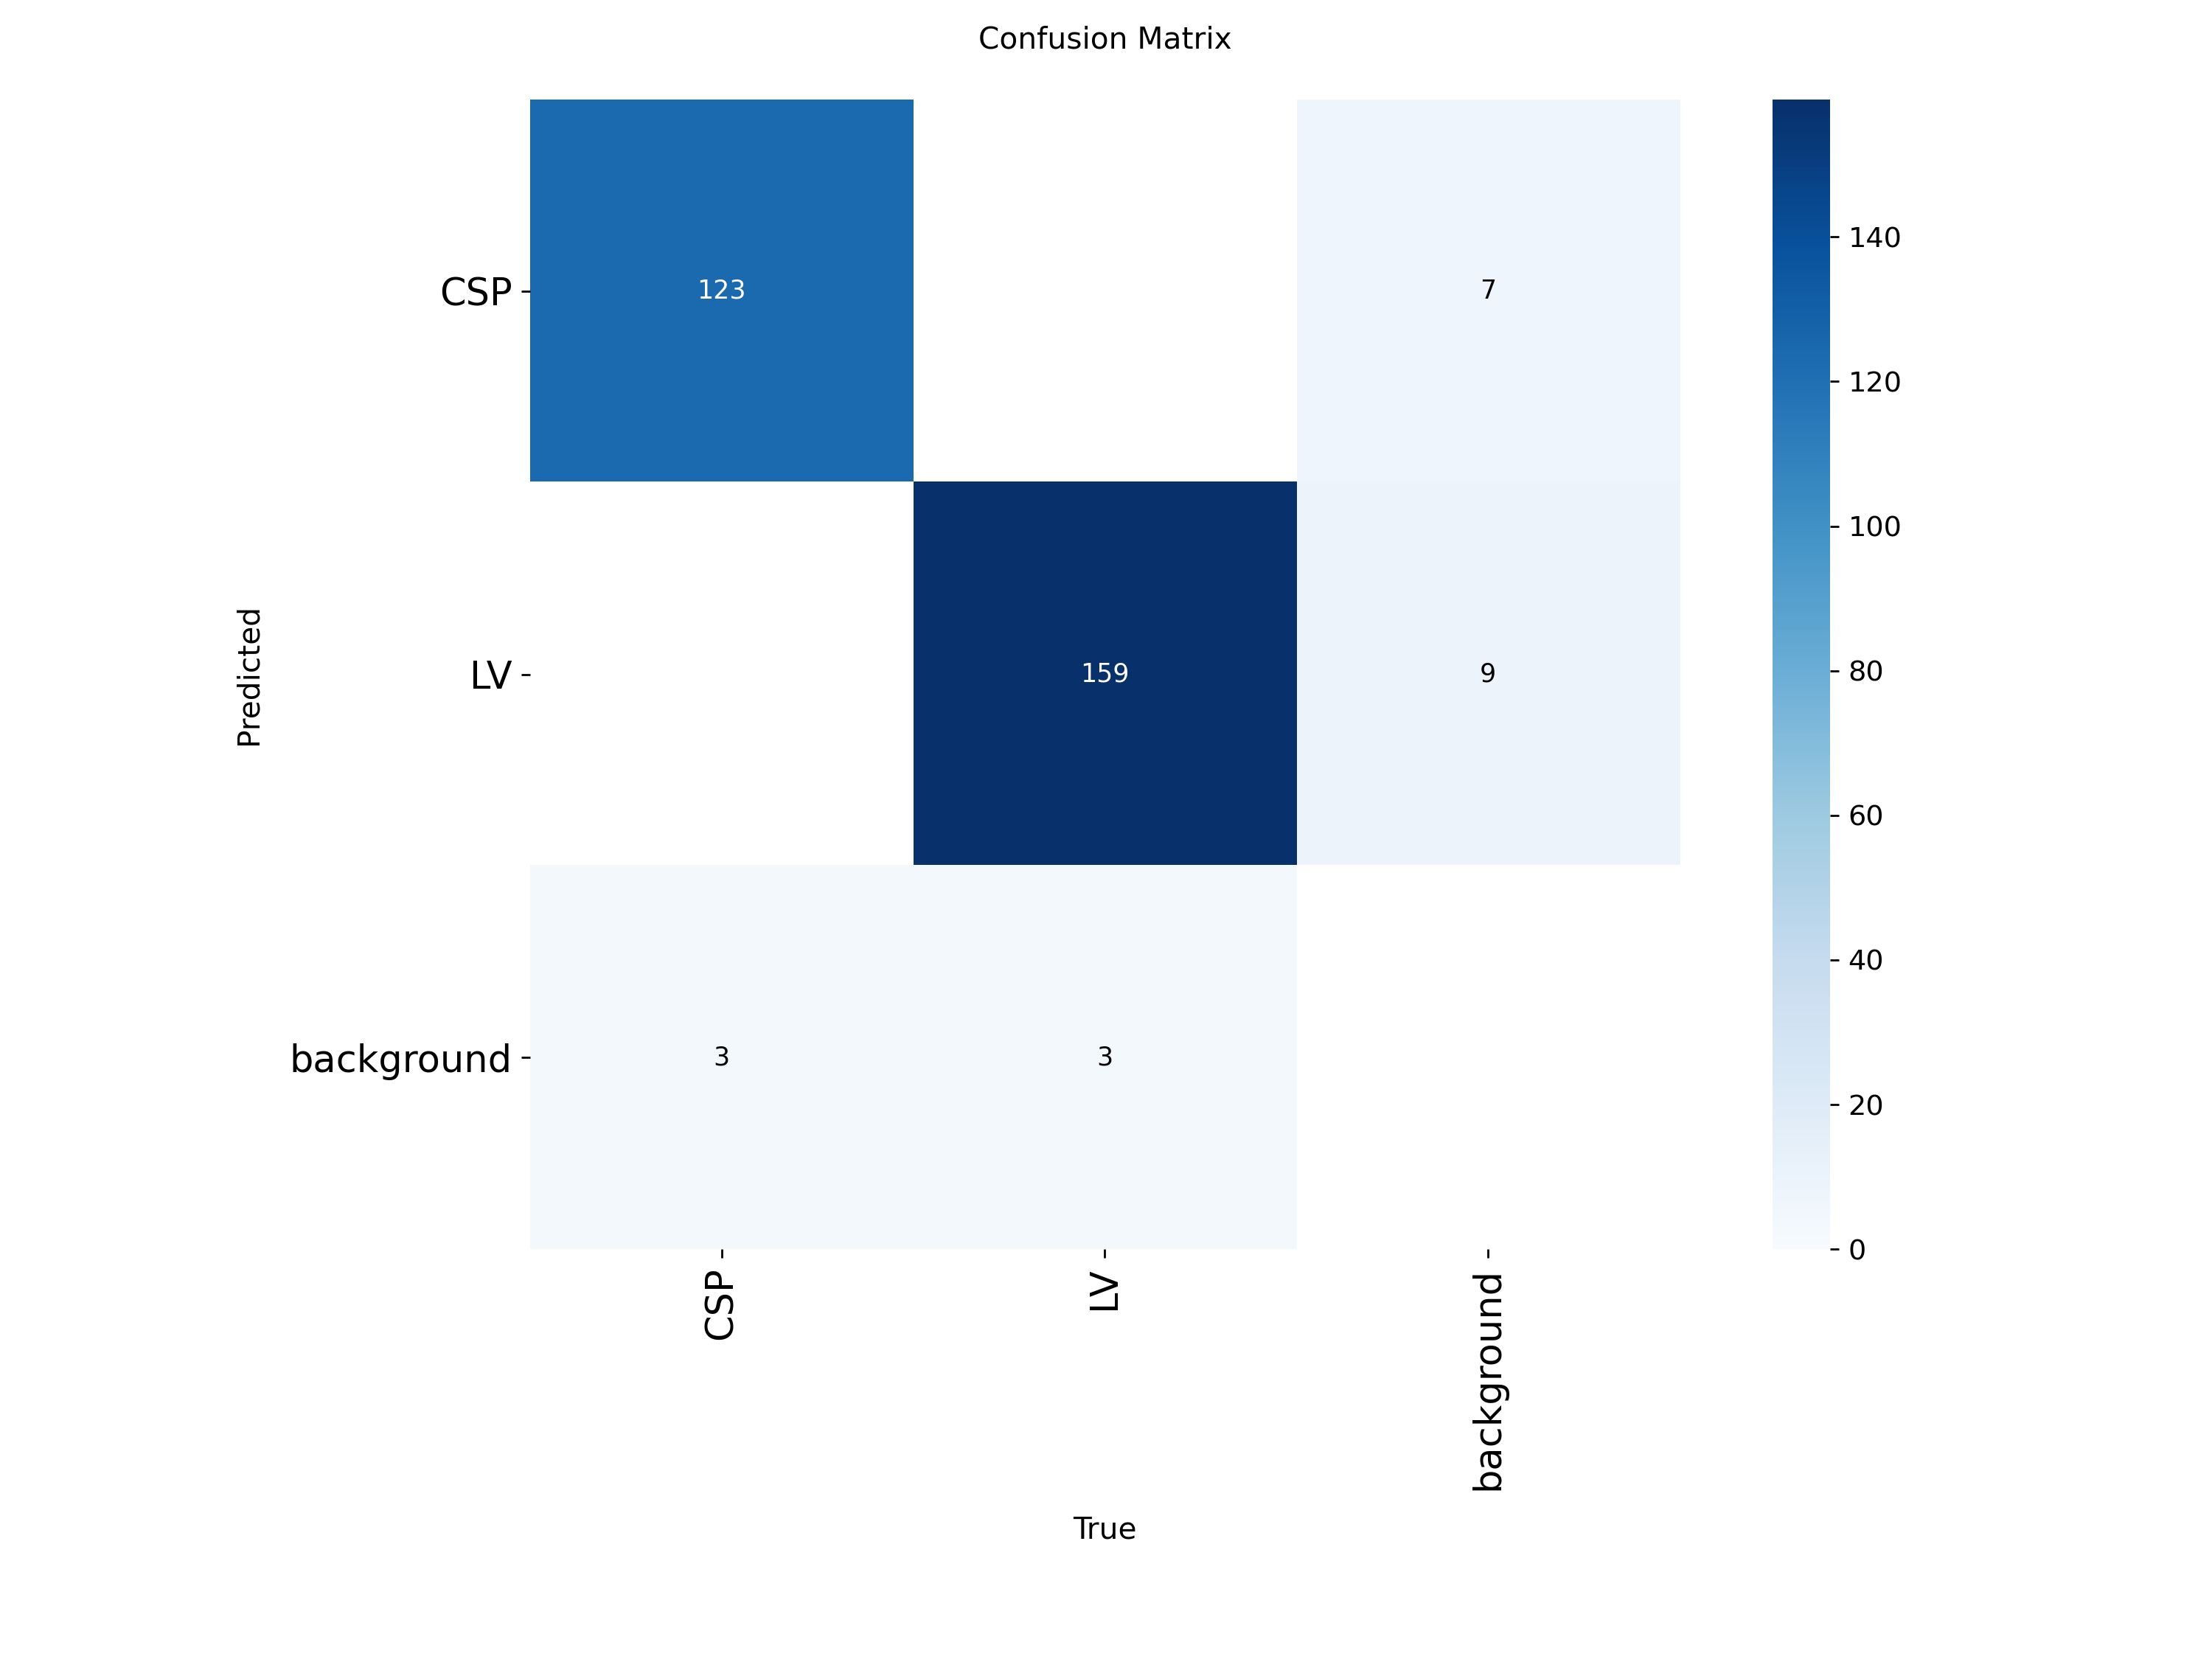

In [29]:
from IPython.display import Image, display

# Path
result_dir = 'runs/detect/runs/detect/trans_ventricular4'

# Plot training curves
result_plots = [
    'results.png',
    'confusion_matrix.png',
]

for plot_name in result_plots:
    plot_path = os.path.join(result_dir, plot_name)
    if os.path.exists(plot_path):
        print(f"\n{plot_name}")
        display(Image(filename=plot_path, width=800))
    else:
        print(f"File tidak ditemukan: {plot_name}")

## 10. Visualisasi Prediksi

Melakukan inferensi pada 6 sampel gambar validasi secara acak dan menampilkan hasil deteksi dengan bounding box. Setiap box dilengkapi label class dan nilai confidence.

Melakukan prediksi pada sample images...



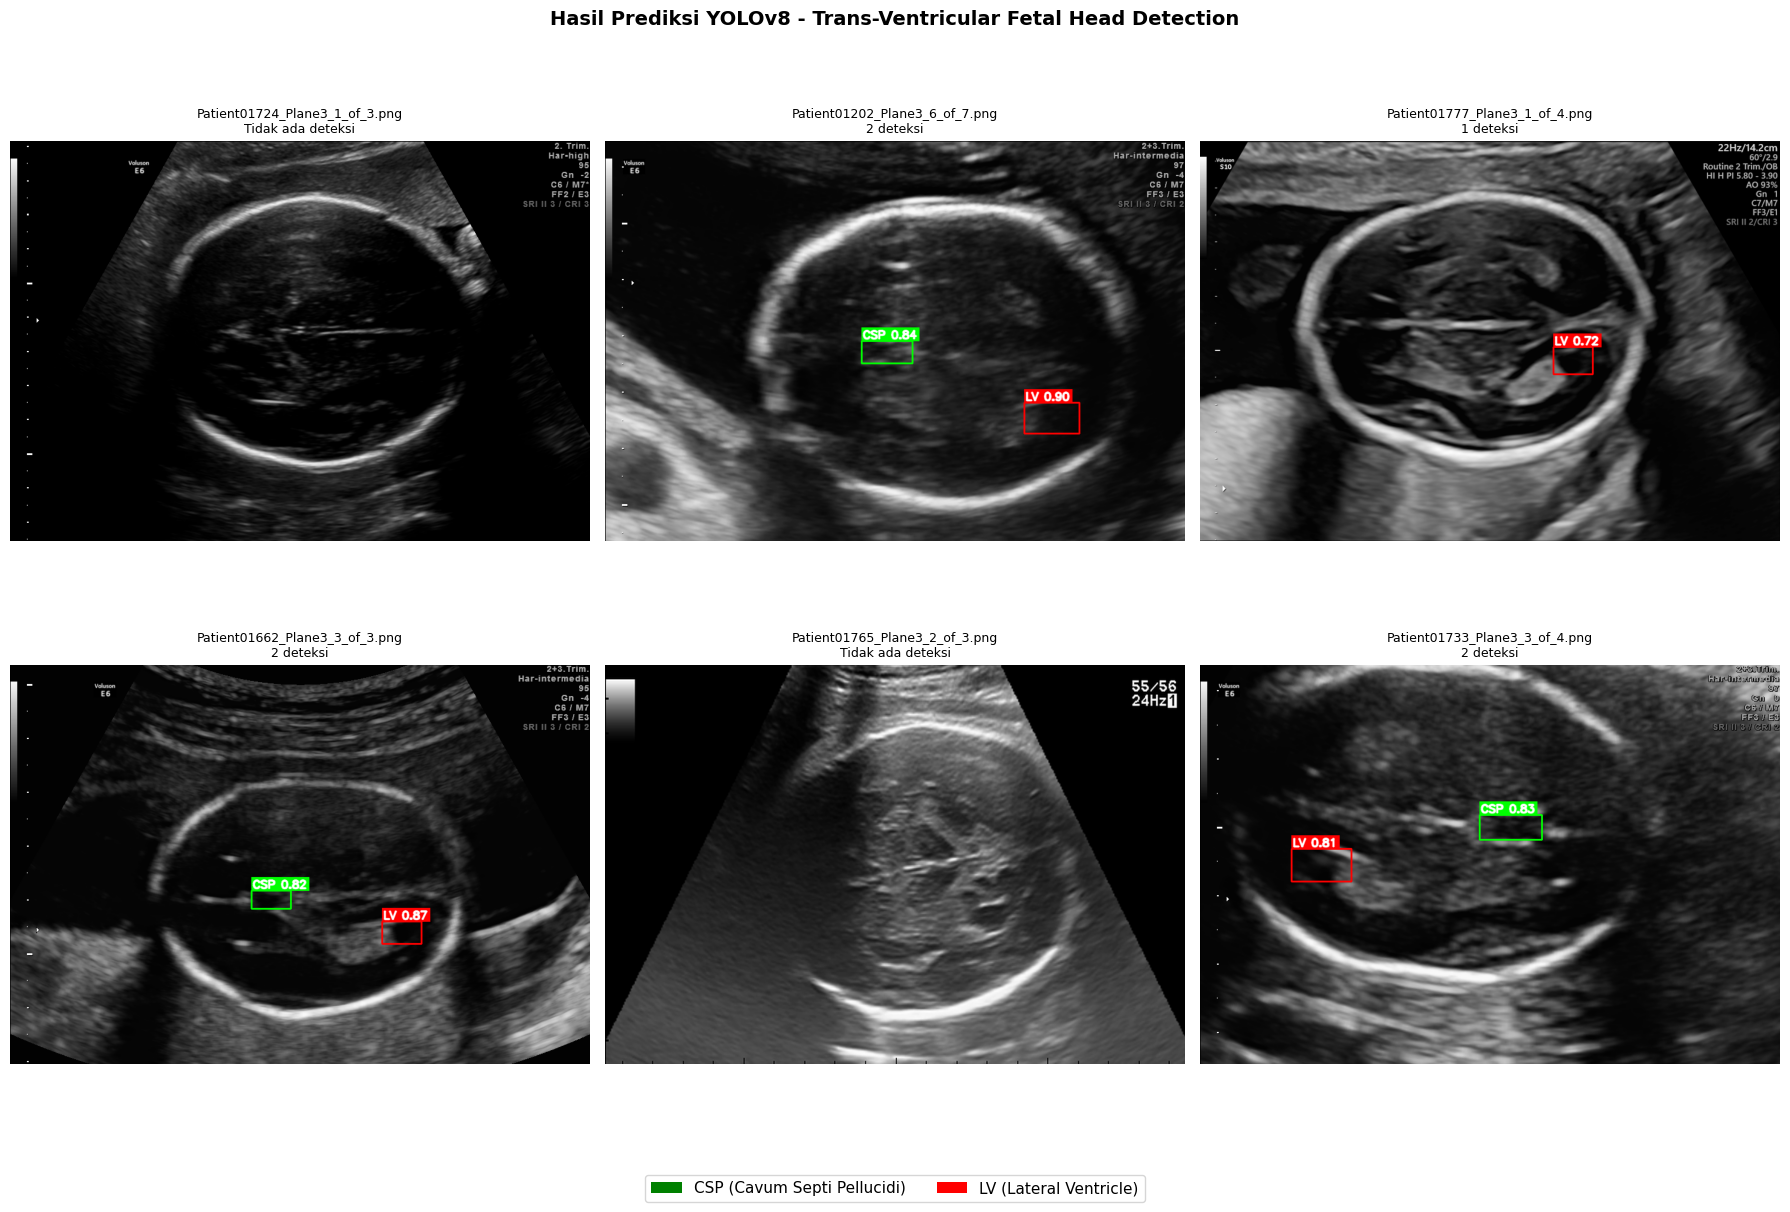

In [30]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Class names dan warna per class
CLASS_NAMES = {0: 'CSP', 1: 'LV'}
CLASS_COLORS = {0: (0, 255, 0), 1: (0, 0, 255)}  # CSP=hijau, LV=merah (BGR)

# Predict on several sample validation images
val_image_files = [f for f in os.listdir(val_images_dir) if f.endswith('.png')]
sample_images = random.sample(val_image_files, min(6, len(val_image_files)))

print("Melakukan prediksi pada sample images...\n")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, img_name in enumerate(sample_images):
    img_path = os.path.join(val_images_dir, img_name)

    # Predict (tanpa save ke disk)
    results = best_model.predict(
        source=img_path,
        conf=0.25,
        save=False,   # tidak perlu simpan ke disk
        verbose=False
    )

    # Baca gambar asli dengan OpenCV
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    result = results[0]
    boxes = result.boxes

    # Gambar bounding box
    if boxes is not None and len(boxes) > 0:
        for box in boxes:
            # Koordinat xyxy (pixel)
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            cls_id = int(box.cls[0].cpu().numpy())
            conf = float(box.conf[0].cpu().numpy())
            label = f"{CLASS_NAMES.get(cls_id, cls_id)} {conf:.2f}"

            # Warna (RGB untuk matplotlib)
            color_bgr = CLASS_COLORS.get(cls_id, (255, 255, 0))
            color_rgb = color_bgr[::-1]  # BGR → RGB

            # Gambar rectangle
            img_rgb = cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color_rgb, 2)

            # Background label
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            img_rgb = cv2.rectangle(img_rgb, (x1, y1 - th - 8), (x1 + tw + 4, y1), color_rgb, -1)

            # Teks label
            img_rgb = cv2.putText(
                img_rgb, label,
                (x1 + 2, y1 - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                (255, 255, 255),  # teks putih
                2, cv2.LINE_AA
            )

        det_info = f"{len(boxes)} deteksi"
    else:
        det_info = "Tidak ada deteksi"

    axes[idx].imshow(img_rgb)
    axes[idx].set_title(f"{img_name}\n{det_info}", fontsize=9)
    axes[idx].axis('off')

# Sembunyikan subplot kosong jika gambar < 6
for idx in range(len(sample_images), 6):
    axes[idx].axis('off')

# Tambah legenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', label='CSP (Cavum Septi Pellucidi)'),
    Patch(facecolor='red',   label='LV (Lateral Ventricle)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=11,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Hasil Prediksi YOLOv8 - Trans-Ventricular Fetal Head Detection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Menyimpan Hasil ke Google Drive

Menyimpan seluruh output ke Google Drive, meliputi bobot model terbaik (`best_model.pt`), file metrik evaluasi (`evaluation_results.txt`), plot training, confusion matrix, dan visualisasi prediksi (`prediction_visualization.png`).

Model disimpan: /content/drive/MyDrive/ipynb-project/Trans-ventricular/results/best_model.pt
Metrics disimpan: /content/drive/MyDrive/ipynb-project/Trans-ventricular/results/evaluation_results.txt
Plot disimpan: results.png
Plot disimpan: confusion_matrix.png


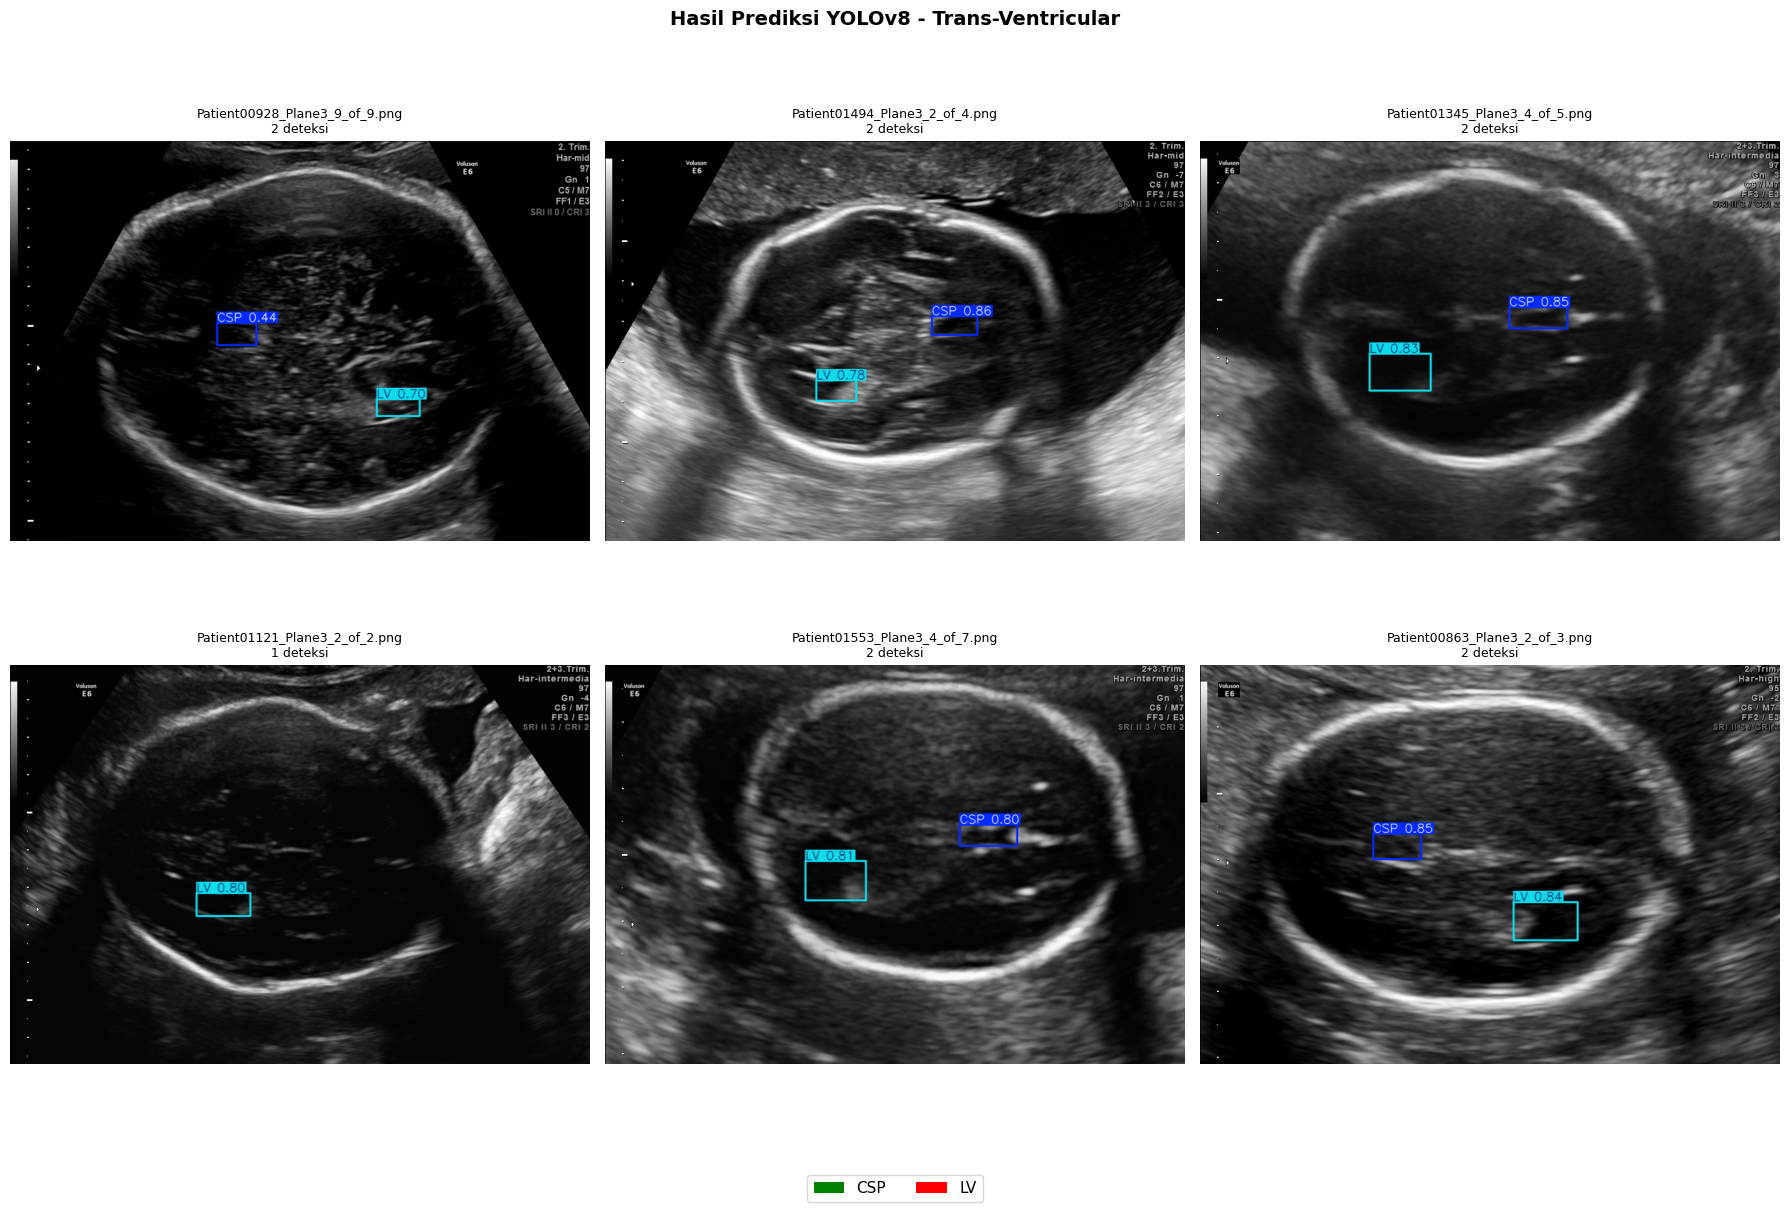

Visualisasi prediksi disimpan: prediction_visualization.png

Semua hasil disimpan di: /content/drive/MyDrive/ipynb-project/Trans-ventricular/results

File yang disimpan:
  - best_model.pt
  - evaluation_results.txt
  - results.png
  - confusion_matrix.png
  - prediction_visualization.png


In [32]:
import shutil, random
from matplotlib.patches import Patch

# Path to the latest training results
result_dir = 'runs/detect/runs/detect/trans_ventricular4'

# Save the evaluation results to Google Drive
save_dir = '/content/drive/MyDrive/ipynb-project/Trans-ventricular/results'
os.makedirs(save_dir, exist_ok=True)

# Copy best weights
best_weight_src = os.path.join(result_dir, 'weights/best.pt')
best_weight_dst = os.path.join(save_dir, 'best_model.pt')
if os.path.exists(best_weight_src):
    shutil.copy2(best_weight_src, best_weight_dst)
    print(f"Model disimpan: {best_weight_dst}")

# Save metrics to text file
metrics_file = os.path.join(save_dir, 'evaluation_results.txt')
with open(metrics_file, 'w') as f:
    f.write("="*60 + "\n")
    f.write("HASIL EVALUASI MODEL - Trans-Ventricular Object Detection\n")
    f.write("="*60 + "\n\n")
    f.write(f"mAP@0.5      : {val_results.box.map50:.4f}\n")
    f.write(f"mAP@0.5:0.95 : {val_results.box.map:.4f}\n")
    f.write(f"Precision    : {val_results.box.mp:.4f}\n")
    f.write(f"Recall       : {val_results.box.mr:.4f}\n\n")
    f.write("Per-Class Metrics:\n")
    for i, class_name in enumerate(['CSP', 'LV']):
        if i < len(val_results.box.maps):
            f.write(f"\n{class_name}:\n")
            f.write(f"  mAP@0.5   : {val_results.box.maps[i]:.4f}\n")
            f.write(f"  Precision : {val_results.box.p[i]:.4f}\n")
            f.write(f"  Recall    : {val_results.box.r[i]:.4f}\n")

print(f"Metrics disimpan: {metrics_file}")

# Copy plots
plot_files = ['results.png', 'confusion_matrix.png']
for plot_file in plot_files:
    src = os.path.join(result_dir, plot_file)
    if os.path.exists(src):
        dst = os.path.join(save_dir, plot_file)
        shutil.copy2(src, dst)
        print(f"Plot disimpan: {plot_file}")

# Generate & simpan visualisasi prediksi
sample_images = random.sample([f for f in os.listdir(val_images_dir) if f.endswith('.png')], 6)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
for idx, img_name in enumerate(sample_images):
    result  = best_model.predict(source=os.path.join(val_images_dir, img_name), conf=0.25, save=False, verbose=False)[0]
    img_rgb = result.plot()[:, :, ::-1]
    axes[idx].imshow(img_rgb)
    axes[idx].set_title(f"{img_name}\n{len(result.boxes)} deteksi", fontsize=9)
    axes[idx].axis('off')
fig.legend(handles=[Patch(facecolor='green', label='CSP'), Patch(facecolor='red', label='LV')],
           loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Hasil Prediksi YOLOv8 - Trans-Ventricular', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'prediction_visualization.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi prediksi disimpan: prediction_visualization.png")

print(f"\nSemua hasil disimpan di: {save_dir}")
print("\nFile yang disimpan:")
for f in os.listdir(save_dir):
    print(f"  - {f}")